<a href="https://colab.research.google.com/github/vishalc412/AIPOC/blob/Master/LanggraphPOCMultiAgentGroq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langgraph langgraph langsmith langchain_community langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.7/109.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.7/412.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.32
    Uninstalling langchain-core-0.3.32:
      Successfully uninstalled langchain-core-0.3.32


In [2]:
from google.colab import userdata
import os
os.environ['LANGCHAIN_API_KEY'] = userdata.get('langgraph_api_key')
os.environ['GROQ_API_KEY'] = userdata.get('groq_api_key')
os.environ['LANGCHAIN_PROJECT'] = 'langgraph-multimodel-demo'

In [3]:
from langchain_groq import ChatGroq

In [4]:
llm = ChatGroq(groq_api_key=userdata.get('groq_api_key'),model_name='gemma2-9b-it')
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x7cde71bf7710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7cde720a96d0>, model_name='gemma2-9b-it', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
from typing import Annotated
from typing_extensions import TypedDict


## Adding external tools

In [6]:
!pip install arxiv wikipedia

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 3.0 MB/s eta 0:00:00
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11679 sha256=c518a8ef0af0df0089036f572d77bc4f05a2014c69c6a785c334a1b369f40ee0
  Stored in directory: /root/.cache/pip/wheels/8f/ab/cb/45ccc40522d3a1c41e1d2ad53b8f33a62f394011ec38cd71c6
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6047 sha256=4fb559e4961e2fbc0397b502566dedd621c10969cc60ebabe1795ef749a4eb27
  Stored in directory: /root/.cache/pip/wheels/3b/25/2a/105d6a15df6914f4d15047691c6c28f9052cc1173e40285d03
Successfully built wikipedia sgmllib3k


In [7]:
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun, ArxivQueryRun

#Arxiv and wiki tools

arxiv_wrapper = ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=300)
arxiv_tool = ArxivQueryRun(api_wrapper=arxiv_wrapper)

wiki_wrapper = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=300)
wiki_tool = WikipediaQueryRun(api_wrapper=wiki_wrapper)

In [8]:
wiki_tool("who is barak obama")

<ipython-input-8-4a208823cbf9>:1: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  wiki_tool("who is barak obama")


'Page: Barack Obama\nSummary: Barack Hussein Obama II (born August 4, 1961) is an American politician and lawyer who served as the 44th president of the United States from 2009 to 2017. A member of the Democratic Party, he was the first African-American president in U.S. history. Obama previously serv'

In [9]:
arxiv_tool("attention is all you need")

"Published: 2024-07-22\nTitle: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models\nAuthors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini\nSummary: The inference demand for LLMs has skyrocketed in recent months, and serving\nmodels with "

In [10]:
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[str],add_messages]


In [11]:
from langgraph.graph import StateGraph,START,END

graphBuilder = StateGraph(State)

In [12]:
from langchain_groq import ChatGroq
llm= ChatGroq(groq_api_key=userdata.get('groq_api_key'),model_name='gemma2-9b-it')
llm


ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x7cde70f41490>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7cde70efe450>, model_name='gemma2-9b-it', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [13]:
llm_combined_result=llm.bind_tools(tools=[arxiv_tool,wiki_tool])

In [14]:
def ChatBot(state:State):
  return {"messages":[llm_combined_result.invoke(state["messages"])]}

In [15]:
from langgraph.prebuilt import ToolNode,tools_condition

In [21]:
graphBuilder.add_node("chatbot",ChatBot)
graphBuilder.add_edge(START,"chatbot")
tool_node=ToolNode(tools=[arxiv_tool,wiki_tool])
graphBuilder.add_node("tools",tool_node)
graphBuilder.add_conditional_edges(
    "chatbot",tools_condition
)
graphBuilder.add_edge("tools","chatbot")
graphBuilder.add_edge("chatbot",END)

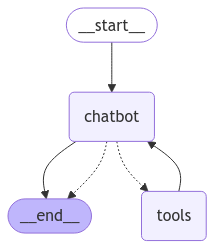

In [22]:
graph=graphBuilder.compile()
graphBuilder.compile()

In [24]:
user_input="tell me about wiki pedia!!!"
events=graph.stream({"messages":["user",user_input]},stream_mode="values")

for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

tell me about wiki pedia!!!
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_7zn1)
 Call ID: call_7zn1
  Args:
    query: wikipedia
================================= Tool Message =================================
Name: wikipedia

Page: Wikipedia
Summary: Wikipedia is a free-content online encyclopedia written and maintained by a community of volunteers, known as Wikipedians, through open collaboration and the wiki software MediaWiki. Wikipedia is the largest and most-read reference work in history, and is consistently ranked
================================== Ai Message ==================================

as a top 10 most popular website worldwide.  It is available in 300 languages and is supported by the Wikimedia Foundation, a non-profit organization.
